In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Loading







In [59]:
accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
usage = pd.read_csv("ravenstack_feature_usage.csv")
support = pd.read_csv("ravenstack_support_tickets.csv")
churn = pd.read_csv("ravenstack_churn_events.csv")


# Data Cleaning and Pre-processing

In [60]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [61]:
subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [62]:
usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [63]:
support.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [64]:
churn.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


## Finding Missing Values

In [65]:
def missing_summary(df, name):
    print(f"\n===== {name.upper()} DATASET =====")

    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100

    summary = pd.DataFrame({
        'missing_count': missing_count,
        'missing_percent': missing_percent
    })

    summary = summary[summary['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

    print(summary)
    return summary

In [66]:
missing_accounts = missing_summary(accounts, "accounts")
missing_subscriptions = missing_summary(subscriptions, "subscriptions")
missing_usage = missing_summary(usage, "usage")
missing_support = missing_summary(support, "support")
missing_churn = missing_summary(churn, "churn")


===== ACCOUNTS DATASET =====
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

===== SUBSCRIPTIONS DATASET =====
          missing_count  missing_percent
end_date           4514            90.28

===== USAGE DATASET =====
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

===== SUPPORT DATASET =====
                    missing_count  missing_percent
satisfaction_score            825            41.25

===== CHURN DATASET =====
               missing_count  missing_percent
feedback_text            148        24.666667


In [67]:
subscriptions['churn'] = subscriptions['end_date'].notnull().astype(int)

In [68]:
from datetime import datetime

today = pd.Timestamp.today()

subscriptions['end_date_filled'] = subscriptions['end_date'].fillna(today)

In [69]:
support['satisfaction_score'] = support['satisfaction_score'].fillna(
    support['satisfaction_score'].median()
)

In [70]:
support['gave_feedback'] = support['satisfaction_score'].notnull().astype(int)

In [71]:
churn['feedback_text'] = churn['feedback_text'].fillna("No feedback")

## Checking for duplicates

In [72]:
def check_duplicates(df, name):
    print(f"\n===== {name.upper()} DUPLICATES =====")

    total_dupes = df.duplicated().sum()
    print("Exact duplicate rows:", total_dupes)

    return df[df.duplicated()]

In [73]:
check_duplicates(accounts, "accounts")
check_duplicates(subscriptions, "subscriptions")
check_duplicates(usage, "usage")
check_duplicates(support, "support")
check_duplicates(churn, "churn")


===== ACCOUNTS DUPLICATES =====
Exact duplicate rows: 0

===== SUBSCRIPTIONS DUPLICATES =====
Exact duplicate rows: 0

===== USAGE DUPLICATES =====
Exact duplicate rows: 0

===== SUPPORT DUPLICATES =====
Exact duplicate rows: 0

===== CHURN DUPLICATES =====
Exact duplicate rows: 0


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text


# Data Analysis:

In [74]:
# Ensure date is datetime
usage['usage_date'] = pd.to_datetime(usage['usage_date'])

usage_agg = usage.groupby('subscription_id').agg(
    total_usage=('usage_count', 'sum'),
    avg_usage=('usage_count', 'mean'),
    total_duration=('usage_duration_secs', 'sum'),
    avg_duration=('usage_duration_secs', 'mean'),
    total_errors=('error_count', 'sum'),
    active_days=('usage_date', 'nunique'),
    features_used=('feature_name', 'nunique'),
    beta_usage=('is_beta_feature', 'sum')
).reset_index()

usage_agg.head()

,subscription_id,total_usage,avg_usage,total_duration,avg_duration,total_errors,active_days,features_used,beta_usage
0,S-001561,48,9.600,21604,4320.80,3,5,5,0
1,S-0027d3,44,11.000,20848,5212.00,0,4,3,0
2,S-003647,71,8.875,13018,1627.25,3,8,8,2
3,S-003fc0,43,10.750,11933,2983.25,1,4,4,0
4,S-004d19,18,9.000,5616,2808.00,0,2,2,0


In [75]:
# --- Ensure dates ---
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])

# --- Churn flag ---
subscriptions['churn'] = subscriptions['end_date'].notnull().astype(int)

# --- Tenure ---
today = pd.Timestamp.today()
subscriptions['end_date_filled'] = subscriptions['end_date'].fillna(today)
subscriptions['tenure_days'] = (
    subscriptions['end_date_filled'] - subscriptions['start_date']
).dt.days

# --- Merge usage ---
df = subscriptions.merge(usage_agg, on='subscription_id', how='left')

# --- Fill missing usage (inactive users)
usage_cols = [
    'total_usage','avg_usage','total_duration','avg_duration',
    'total_errors','active_days','features_used','beta_usage'
]
df[usage_cols] = df[usage_cols].fillna(0)

df.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,end_date_filled,tenure_days,total_usage,avg_usage,total_duration,avg_duration,total_errors,active_days,features_used,beta_usage
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,2024-04-12 00:00:00.000000,111,63.0,10.500000,26418.0,4403.000000,2.0,6.0,6.0,1.0
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,2026-04-26 19:48:54.971014,684,36.0,9.000000,6819.0,1704.750000,6.0,4.0,4.0,0.0
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,2026-04-26 19:48:54.971014,517,25.0,8.333333,13877.0,4625.666667,2.0,3.0,3.0,0.0
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,2024-12-13 00:00:00.000000,20,65.0,9.285714,22943.0,3277.571429,5.0,7.0,7.0,0.0
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,2026-04-26 19:48:54.971014,837,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0


In [76]:
print("Total customers:", df['subscription_id'].nunique())
print("Churn rate:", df['churn'].mean())
print("Avg tenure (days):", df['tenure_days'].mean())

Total customers: 5000
Churn rate: 0.0972
Avg tenure (days): 595.1684


* Overall KPI overview

# Churn Patterns: Who is churning?

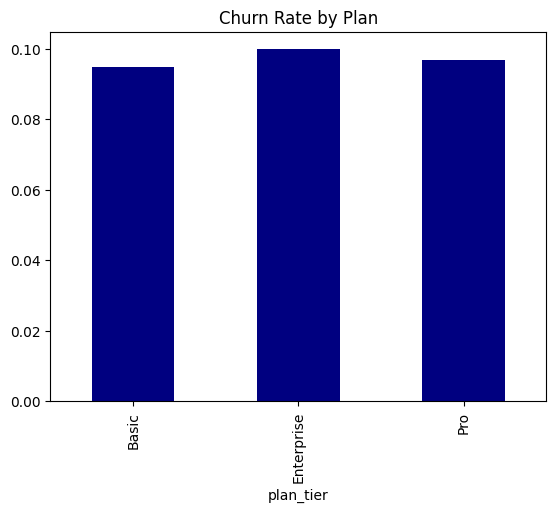

In [77]:
churn_by_plan = df.groupby('plan_tier')['churn'].mean()
churn_by_plan.plot(kind='bar', title='Churn Rate by Plan', color= '#000080')
plt.show()

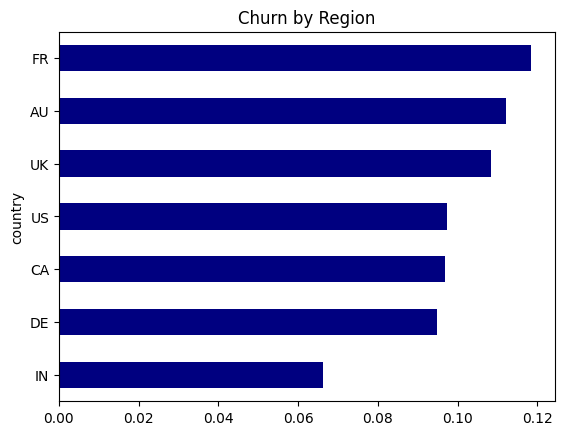

In [78]:
df = df.merge(accounts[['account_id', 'country']], on='account_id', how='left')


churn_by_region = df.groupby('country')['churn'].mean()
churn_by_region.sort_values().plot(kind='barh', title='Churn by Region', color= '#000080')
plt.show()

# Customer Lifetime Trends

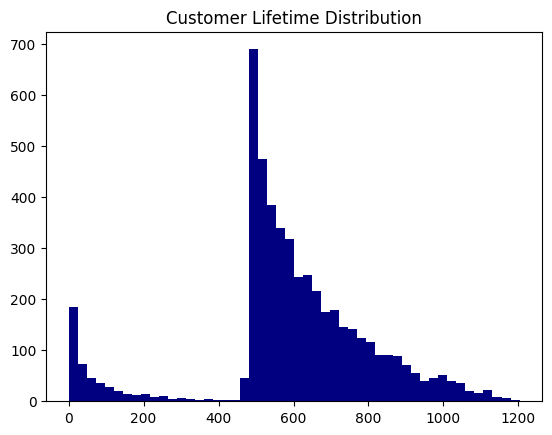

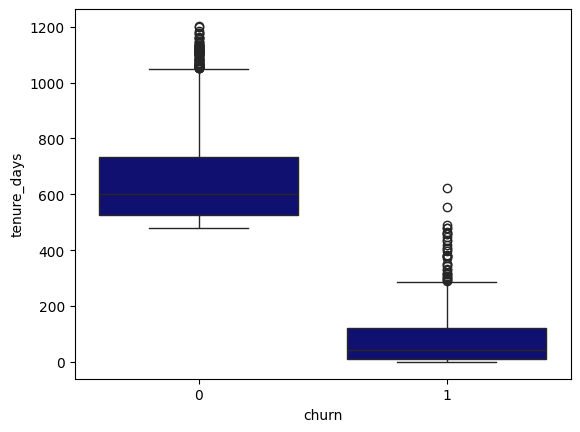

In [79]:
df['tenure_days'].describe()

plt.hist(df['tenure_days'], bins=50, color= '#000080')
plt.title("Customer Lifetime Distribution")
plt.show()

import seaborn as sns
sns.boxplot(x='churn', y='tenure_days', data=df, color= '#000080')
plt.show()

# Cohort Retention Analysis

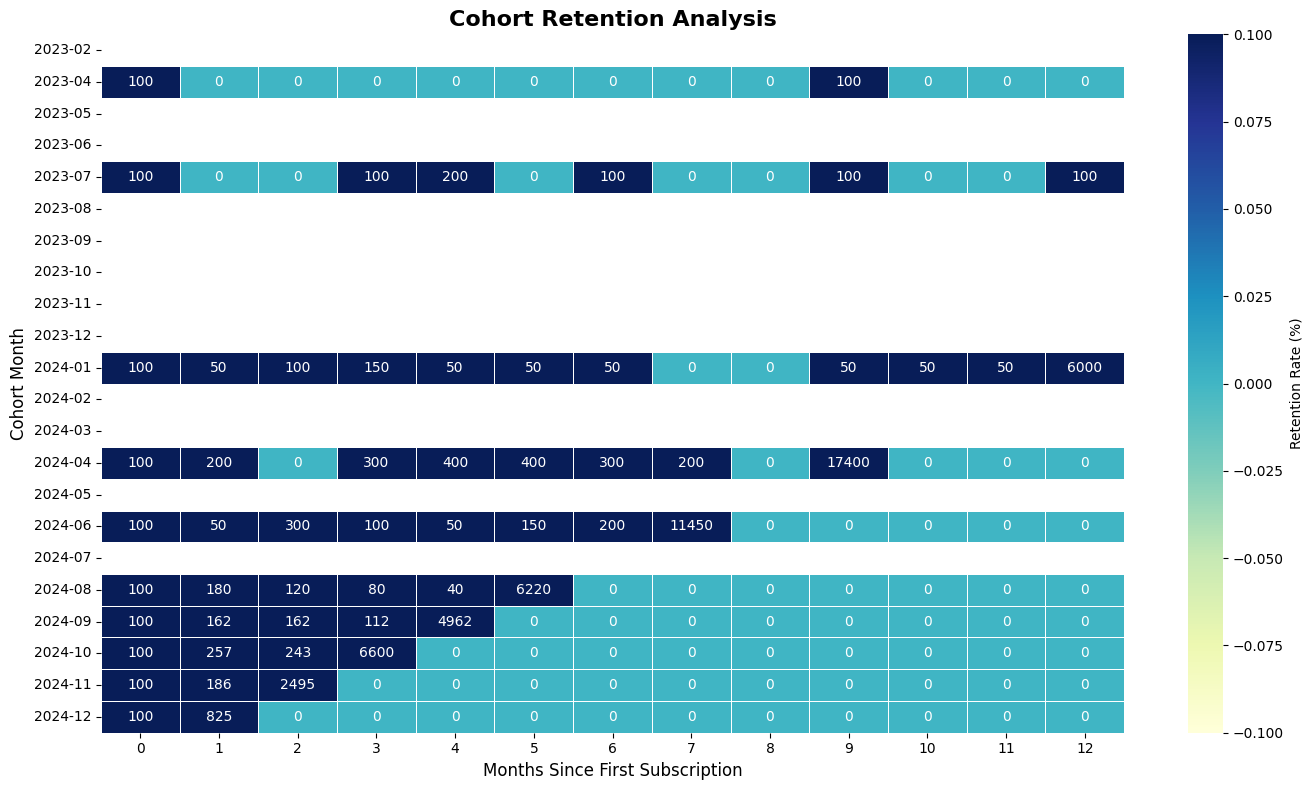

In [80]:
# Convert dates to datetime
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date_filled'] = pd.to_datetime(df['end_date_filled'])

# For active customers (no churn), set end_date to today or analysis date
analysis_date = pd.Timestamp('2025-01-01')  # Pick a fixed analysis date
df['cohort_month'] = df['start_date'].dt.to_period('M')

# Create activity month (when they were active)
# For churned customers: use actual churn date
# For active customers: use analysis date
df['activity_month'] = df['end_date_filled'].where(
    df['churn'] == 1,  # if churned
    analysis_date       # if still active
)
df['activity_month'] = df['activity_month'].dt.to_period('M')

# Calculate cohort index (months since start)
df['cohort_index'] = (
    (df['activity_month'].dt.year - df['cohort_month'].dt.year) * 12 +
    (df['activity_month'].dt.month - df['cohort_month'].dt.month)
)

# Filter to reasonable cohort index
df = df[df['cohort_index'] <= 12]

# Pivot table: Count DISTINCT active subscriptions each month
cohort = df.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='subscription_id',
    aggfunc='nunique',  # not 'count'
    fill_value=0
)

# Calculate retention rate
retention = cohort.divide(cohort[0], axis=0) * 100


plt.figure(figsize=(14, 8))
sns.heatmap(
    retention,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title("Cohort Retention Analysis", fontsize=16, fontweight='bold')
plt.xlabel("Months Since First Subscription", fontsize=12)
plt.ylabel("Cohort Month", fontsize=12)
plt.tight_layout()
plt.show()

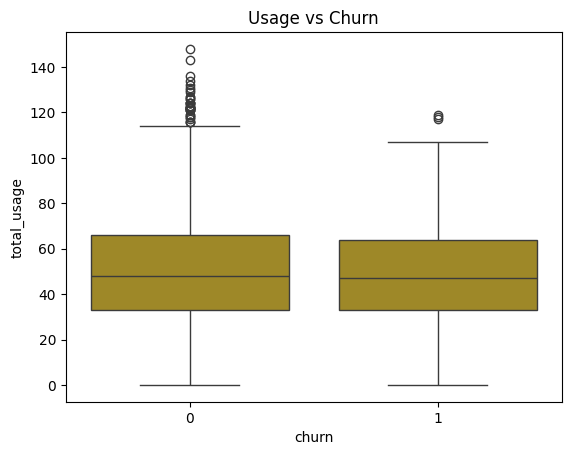

In [81]:
sns.boxplot(x='churn', y='total_usage', data=df, color= '#B29414')
plt.title("Usage vs Churn")
plt.show()

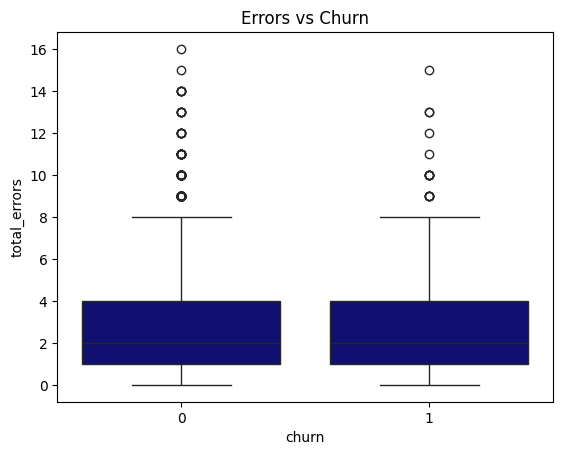

In [82]:
sns.boxplot(x='churn', y='total_errors', data=df, color= '#000080')
plt.title("Errors vs Churn")
plt.show()

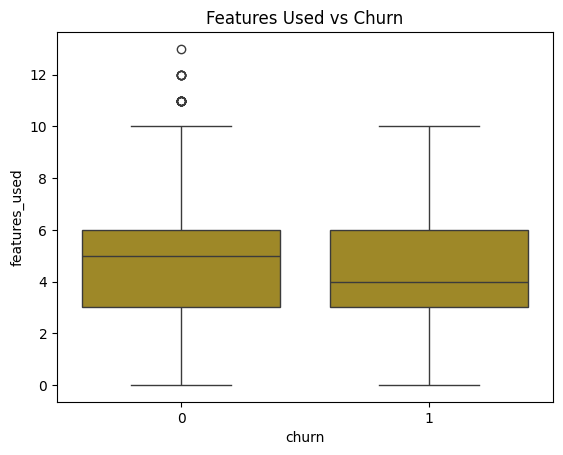

In [83]:
sns.boxplot(x='churn', y='features_used', data=df, color= '#B29414')
plt.title("Features Used vs Churn")
plt.show()

Missing columns: []


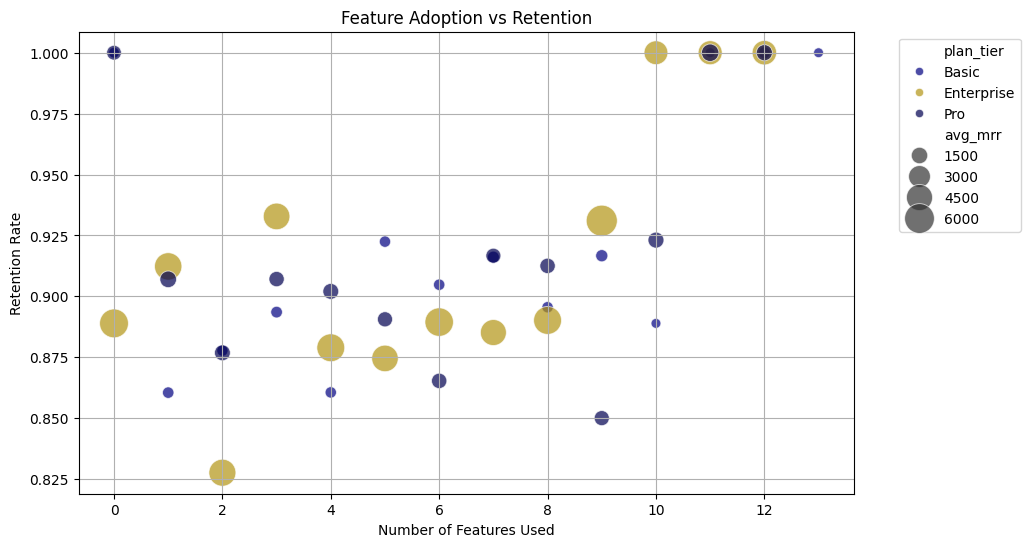

In [84]:
df['retained'] = 1 - df['churn_flag']

required_cols = ['features_used', 'plan_tier', 'retained', 'mrr_amount']
missing = [col for col in required_cols if col not in df.columns]
print("Missing columns:", missing)

# Aggregate to customer/segment level
agg_df = df.groupby(['features_used', 'plan_tier']).agg(
    retention_rate=('retained', 'mean'),
    avg_mrr=('mrr_amount', 'mean'),
    count=('plan_tier', 'size')   # optional but useful for debugging / sizing reliability
).reset_index()

# Ensure consistent data types
agg_df['plan_tier'] = agg_df['plan_tier'].astype(str)

# Optional: sort for consistency
agg_df = agg_df.sort_values(['plan_tier', 'features_used'])



agg_df['plan_tier'] = agg_df['plan_tier'].astype(str)

# Force stable ordering of categories
tier_order = sorted(agg_df['plan_tier'].unique())

custom_palette = ["#000080", "#B29414", "#000050"]


sns.set_palette(custom_palette)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=agg_df,
    x='features_used',
    y='retention_rate',
    size='avg_mrr',
    hue='plan_tier',
    sizes=(50, 500),
    alpha=0.7
)

plt.title('Feature Adoption vs Retention')
plt.xlabel('Number of Features Used')
plt.ylabel('Retention Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()

# Exports

In [85]:
accounts.to_csv("accounts_cleaned.csv", index=False)
subscriptions.to_csv("subscriptions_cleaned", index=False)
usage.to_csv("usage_cleaned.csv", index=False)
support.to_csv("support_tickets_cleaned.csv", index=False)
churn.to_csv("churn_cleaned.csv", index=False)
df.to_csv("df_cleaned.csv", index= False)